# Ping Pong Ball Prediction Using Transfer Learning:

Inputs:
- x y z (frame 1)
- x y z (frame 2)
- x y z (frame 3)
- x y z (frame 4)
- dt12
- dt23
- dt34

Outputs:
- x y z (interception)
- vx vy vz
- t_hit
- is_reachable



## Importing the Libraries

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

### Importing the Dataset

In [2]:
dataset = pd.read_csv('../learning_data/synthetic_data/synthetic_intercept_dataset_4p.csv')

In [3]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 33 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   x1                     20000 non-null  float64
 1   y1                     20000 non-null  float64
 2   z1                     20000 non-null  float64
 3   x2                     20000 non-null  float64
 4   y2                     20000 non-null  float64
 5   z2                     20000 non-null  float64
 6   x3                     20000 non-null  float64
 7   y3                     20000 non-null  float64
 8   z3                     20000 non-null  float64
 9   x4                     20000 non-null  float64
 10  y4                     20000 non-null  float64
 11  z4                     20000 non-null  float64
 12  dt12                   20000 non-null  float64
 13  dt23                   20000 non-null  float64
 14  dt34                   20000 non-null  float64
 15  x_

In [4]:
dataset.describe()

,x1,y1,z1,x2,y2,z2,x3,y3,z3,x4,...,bounces_before_hit,has_bounce_before_hit,intercept_valid,x0,y0,z0,vx0,vy0,vz0,gravity_z_mm_s2
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,...,20000.00000,20000.000000,20000.0,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,-2.990129,2590.172351,-802.581541,-2.656957,2519.592891,-832.483335,-2.304698,2448.931470,-859.326055,-1.949930,...,1.15790,0.957300,1.0,-3.002031,2590.232389,-802.538807,21.411513,-4558.956524,-2018.513707,-9809.639317
std,614.299315,373.343405,202.149465,592.157083,395.741541,200.052111,570.839544,418.972080,194.671850,550.650459,...,0.46731,0.202185,0.0,614.305571,373.309348,202.151102,2061.024053,1859.406105,1795.184466,97.913423
min,-1062.500000,1940.000000,-1150.740000,-1061.536328,1776.550034,-1156.988093,-1056.445527,1604.855174,-1164.739814,-1055.117686,...,0.00000,0.000000,1.0,-1062.384490,1940.120356,-1150.735699,-5164.450753,-10000.000000,-5497.253620,-10209.809076
25%,-539.191936,2267.155817,-979.297587,-519.822611,2178.830301,-1010.815954,-500.518856,2089.878762,-1040.243884,-479.036646,...,1.00000,1.000000,1.0,-539.178082,2267.704934,-978.916757,-1467.004211,-5808.485112,-3541.006662,-9876.283471
50%,1.071048,2591.825875,-803.514690,1.247438,2520.063072,-836.553316,-0.726154,2450.577006,-871.212380,0.283018,...,1.00000,1.000000,1.0,1.554360,2590.522252,-803.748323,4.159903,-4286.450764,-2072.705454,-9808.918694
75%,523.227029,2911.850101,-628.909431,505.608037,2861.141222,-661.457097,488.327914,2809.768801,-695.604602,469.261422,...,1.00000,1.000000,1.0,523.385079,2911.796123,-627.970012,1511.318216,-3101.049439,-580.295654,-9744.596323
max,1062.500000,3240.000000,-450.740000,1057.943687,3224.045454,-422.429427,1064.884618,3215.380420,-395.212409,1063.055500,...,2.00000,1.000000,1.0,1062.443827,3239.979774,-450.750184,5289.275723,-694.656523,2396.531370,-9394.566257


### Pre-Processing

### Separating the Input and Outputs

In [5]:
x = dataset.iloc[:, :15]
y = dataset.iloc[:, 15:-11]

In [6]:
# View the inputs
print(x)

                x1           y1           z1          x2           y2  \
0      -132.058699  3057.523708  -662.179031  -82.466693  3017.418410   
1      -584.587732  2810.232859  -845.197842 -542.602799  2732.367571   
2      -463.923739  2323.686782  -686.972776 -431.633139  2241.034089   
3      -405.913484  2690.671817 -1028.383000 -382.658841  2624.862652   
4     -1020.486165  3015.607130  -522.943537 -979.316728  2991.877753   
...            ...          ...          ...         ...          ...   
19995   605.924698  2245.109311  -740.275401  560.912126  2141.616688   
19996   323.510392  2775.890467  -665.877500  320.281051  2716.107020   
19997  -173.122842  2074.394606  -497.553785 -174.333021  2000.896372   
19998   741.263201  3171.915854  -735.986250  732.710053  3137.053812   
19999   447.674978  3018.537533 -1147.624638  438.756004  2990.504651   

                z2          x3           y3           z3          x4  \
0      -648.270752  -38.897514  2985.590851  -646.3

In [7]:
# View the outputs
print(y)

             x_hit        y_hit       z_hit       vx_hit       vy_hit  \
0      1371.275360  1931.111771 -753.009373  2680.640491 -2009.045581   
1       672.122875   339.503341 -849.512710  2408.539439 -4752.413176   
2       430.631575   258.957866 -618.039625  2594.755955 -5978.881216   
3       653.011371   304.645200 -927.229509  2266.709670 -5081.574979   
4      1211.472546  1626.324388 -644.120844  2652.436758 -1652.208469   
...            ...          ...         ...          ...          ...   
19995  -171.426557   295.878314 -381.383568 -2982.099175 -7499.501738   
19996   345.506192   -10.199907 -585.696882    33.884928 -4940.602430   
19997  -124.287878   352.173310 -806.984357   118.296506 -4203.214330   
19998  -114.891670    -5.540828 -853.251978  -650.391401 -2415.901159   
19999   512.246442    41.895576 -107.768470    43.912447 -1987.875201   

            vz_hit     t_hit  
0      1488.570757  0.508683  
1      -556.728367  0.476885  
2      1892.796767  0.299106  

In [8]:
x = x.values
y = y.values

### Splitting the Dataset into the Training set and Test set

In [9]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1) Build reachability vector from your full dataset
# (change column name if needed)
r = dataset["is_reachable"].to_numpy().astype(int)

# 2) Split x, y, and r together (important)
x_train, x_test, y_train, y_test, r_train, r_test = train_test_split(
    x, y, r,
    test_size=0.05,
    random_state=33,
    stratify=r   # recommended
)

# 3) Keep full test copy
x_test_all = x_test.copy()
y_test_all = y_test.copy()

# 4) Reachable-only adjusted test set
mask_reach = (r_test == 1)
x_test_reach = x_test_all[mask_reach].copy()
y_test_reach = y_test_all[mask_reach].copy()


In [10]:
print(x_train.shape)
print(x_test_all.shape)
print(x_test_reach.shape)
print(y_train.shape)
print(y_test_all.shape)
print(y_test_reach.shape)

(19000, 15)
(1000, 15)
(237, 15)
(19000, 7)
(1000, 7)
(237, 7)


### Feature Scaling

In [11]:
from sklearn.preprocessing import StandardScaler

scx = StandardScaler()
scy = StandardScaler()

x_train = scx.fit_transform(x_train)
x_test_all = scx.transform(x_test_all)
x_test_reach = scx.transform(x_test_reach)

y_train = scy.fit_transform((y_train))
y_test_all = scy.transform((y_test_all))
y_test_reach = scy.transform((y_test_reach))

## The ANN Model Initialization

In [12]:
ball_predictor = tf.keras.models.Sequential()

### Constructing the Model

In [13]:
ball_predictor.add(tf.keras.layers.Dense(units=15, activation='relu')) # 15 input features
ball_predictor.add(tf.keras.layers.Dense(units=32, activation='relu')) # hiddel layer 1
ball_predictor.add(tf.keras.layers.Dense(units=32, activation='relu')) # hidden layer 2
ball_predictor.add(tf.keras.layers.Dense(units=32, activation='relu')) # hiddel layer 3
ball_predictor.add(tf.keras.layers.Dense(units=16, activation='relu')) # hiddel layer 4
ball_predictor.add(tf.keras.layers.Dense(units=7, activation='linear')) # 7

In [14]:
ball_predictor.compile(loss='mean_squared_error', optimizer='adam', metrics=['mean_squared_error'])

### Training

In [15]:
p1 = ball_predictor.fit(x_train, y_train, validation_split=0.2, batch_size = 32, epochs = 80,verbose=1)

Epoch 1/80
475/475 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.7421 - mean_squared_error: 0.7421 - val_loss: 0.6706 - val_mean_squared_error: 0.6706
Epoch 2/80
475/475 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6517 - mean_squared_error: 0.6517 - val_loss: 0.5987 - val_mean_squared_error: 0.5987
Epoch 3/80
475/475 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4930 - mean_squared_error: 0.4930 - val_loss: 0.3969 - val_mean_squared_error: 0.3969
Epoch 4/80
475/475 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3287 - mean_squared_error: 0.3287 - val_loss: 0.2894 - val_mean_squared_error: 0.2894
Epoch 5/80
475/475 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2605 - mean_squared_error: 0.2605 - val_loss: 0.2504 - val_mean_squared_error: 0.2504
Epoch 6/80
475/475 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2255 - mean_squared_error: 0.2255 - val_loss: 0.2173 - val_mean_squared_error: 0.2173
Epoch 7/80
475/475 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2007 - mean_squared_error: 0.2007 - val_loss: 0.19

### Learning Curves

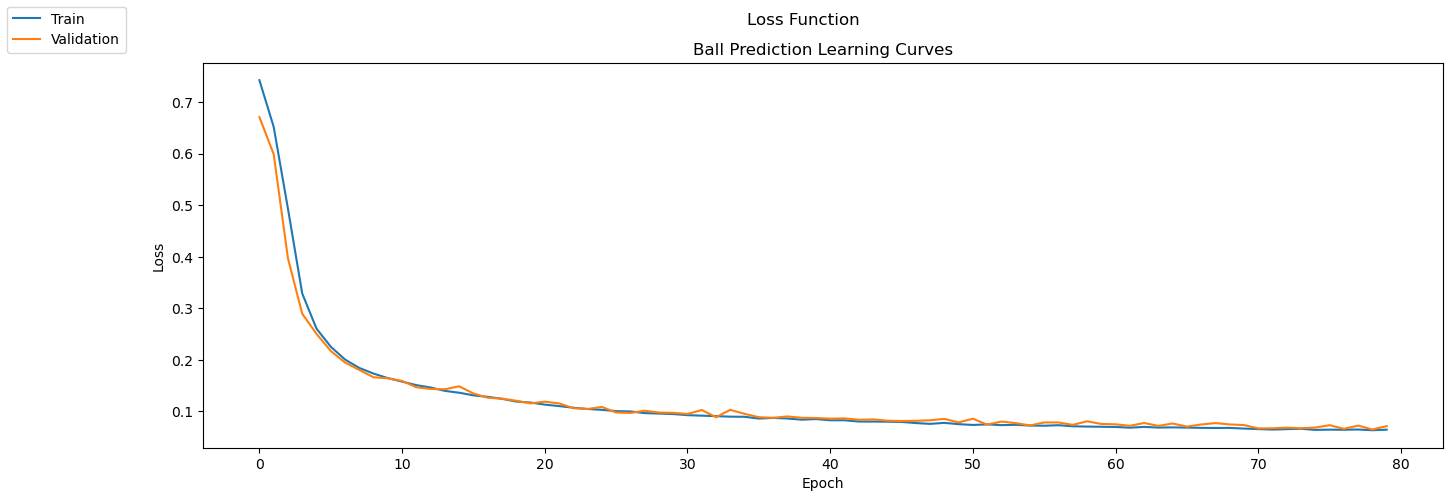

In [16]:
fig, axs = plt.subplots(figsize=(16,5))
fig.suptitle('Loss Function')

axs.plot(p1.history['loss'])
axs.plot(p1.history['val_loss'])
axs.set_title("Ball Prediction Learning Curves")
axs.set(xlabel='Epoch', ylabel='Loss')

fig.legend(labels=['Train', 'Validation'], loc="upper left")
plt.show()

In [17]:
# def eval_regression(name, y_true, y_pred):
#     mae = mean_absolute_error(y_true, y_pred, multioutput='raw_values')
#     rmse = np.sqrt(mean_squared_error(y_true, y_pred, multioutput='raw_values'))
#     print(f"\n{name}")
#     print("MAE per output:", mae)
#     print("RMSE per output:", rmse)

# # If y is scaled, inverse-transform both y_true and y_pred before metrics.
# y_pred_all = ball_predictor.predict(x_test_all)
# y_pred_reach = ball_predictor.predict(x_test_reach)

# # Example for scaled targets:
# # y_pred_all = scy.inverse_transform(y_pred_all); y_test_all_eval = scy.inverse_transform(y_test_all)
# # y_pred_reach = scy.inverse_transform(y_pred_reach); y_test_reach_eval = scy.inverse_transform(y_test_reach)

# eval_regression("All test shots", y_test_all, y_pred_all)
# eval_regression("Reachable-only test shots", y_test_reach, y_pred_reach)

import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error

target_names = ["x_hit", "y_hit", "z_hit", "vx_hit", "vy_hit", "vz_hit", "t_hit"]
target_units = ["mm", "mm", "mm", "mm/s", "mm/s", "mm/s", "ms"]

def eval_with_units(name, model, x_eval, y_eval, y_scaler, y_is_scaled=True, t_hit_in_seconds=True):
    y_pred = model.predict(x_eval, verbose=0)

    # Convert to physical units exactly once
    if y_is_scaled:
        assert y_eval.shape[1] == y_scaler.n_features_in_ == len(target_names)
        y_true_u = y_scaler.inverse_transform(y_eval)
        y_pred_u = y_scaler.inverse_transform(y_pred)
    else:
        y_true_u = y_eval
        y_pred_u = y_pred

    err = y_pred_u - y_true_u
    abs_err = np.abs(err)

    mae = mean_absolute_error(y_true_u, y_pred_u, multioutput="raw_values")
    rmse = np.sqrt(mean_squared_error(y_true_u, y_pred_u, multioutput="raw_values"))
    std_abs = abs_err.std(axis=0)

    # Convert t_hit to ms for reporting (only if stored in seconds)
    if t_hit_in_seconds:
        i = target_names.index("t_hit")
        mae[i] *= 1000.0
        rmse[i] *= 1000.0
        std_abs[i] *= 1000.0

    report = pd.DataFrame({
        "target": target_names,
        "unit": target_units,
        "MAE": mae,
        "RMSE": rmse,
        "STD_abs_error": std_abs,
    })

    print(f"\n{name}")
    print(report.to_string(index=False, float_format=lambda v: f"{v:,.3f}"))

# Run both:
eval_with_units("All test shots", ball_predictor, x_test_all, y_test_all, scy, y_is_scaled=True, t_hit_in_seconds=True)
eval_with_units("Reachable-only test shots", ball_predictor, x_test_reach, y_test_reach, scy, y_is_scaled=True, t_hit_in_seconds=True)




All test shots
target unit     MAE      RMSE  STD_abs_error
 x_hit   mm 109.168   143.484         93.114
 y_hit   mm 100.832   140.630         98.029
 z_hit   mm  80.090   106.394         70.037
vx_hit mm/s 183.637   230.369        139.095
vy_hit mm/s 175.415   220.203        133.113
vz_hit mm/s 671.797 1,060.891        821.085
 t_hit   ms  34.824    49.191         34.743

Reachable-only test shots
target unit     MAE      RMSE  STD_abs_error
 x_hit   mm 110.906   143.539         91.122
 y_hit   mm 112.305   156.766        109.376
 z_hit   mm  61.260    79.614         50.848
vx_hit mm/s 155.839   194.240        115.946
vy_hit mm/s 171.045   214.072        128.727
vz_hit mm/s 808.055 1,256.098        961.680
 t_hit   ms  35.152    47.478         31.914


In [18]:
# Verification 
train_std = scy.scale_ 
rmse_sigma = np.sqrt(0.1084)   # val_mse from curve, e.g. 0.1151
rmse_units = rmse_sigma * train_std

print(rmse_units)


[2.47277621e+02 1.72949722e+02 1.18036912e+02 6.79673469e+02
 6.13621428e+02 7.18888587e+02 9.27351915e-02]


## Loading the Matched Synthetic Dataset (Transfer Learning)

In [19]:
matched_dataset = pd.read_csv('../learning_data/synthetic_matched_data/synthetic_intercept_dataset_4p.csv')
matched_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 33 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   x1                     10000 non-null  float64
 1   y1                     10000 non-null  float64
 2   z1                     10000 non-null  float64
 3   x2                     10000 non-null  float64
 4   y2                     10000 non-null  float64
 5   z2                     10000 non-null  float64
 6   x3                     10000 non-null  float64
 7   y3                     10000 non-null  float64
 8   z3                     10000 non-null  float64
 9   x4                     10000 non-null  float64
 10  y4                     10000 non-null  float64
 11  z4                     10000 non-null  float64
 12  dt12                   10000 non-null  float64
 13  dt23                   10000 non-null  float64
 14  dt34                   10000 non-null  float64
 15  x_h

In [20]:
x_matched = matched_dataset.iloc[:, :15]
y_matched = matched_dataset.iloc[:, 15:-11]


# View the inputs
print(x_matched)
print(y_matched)

x_matched = x_matched.values
y_matched = y_matched.values

              x1           y1           z1          x2           y2  \
0     323.584807  2699.616386  -791.351576  312.387931  2655.585742   
1       4.002104  2543.403984  -691.731292  -17.300255  2452.365308   
2    -281.055862  2618.294362 -1008.380501 -267.684669  2547.361264   
3    -258.737518  2485.995832 -1065.542642 -264.919644  2426.566822   
4     -91.419849  2739.225555  -495.799465  -89.426084  2696.096015   
...          ...          ...          ...         ...          ...   
9995  -27.780133  2573.997800  -486.307230  -18.261295  2459.539324   
9996  154.952661  2472.369146  -986.345042  153.305531  2387.939091   
9997   81.701211  2672.812861  -723.367771   85.805068  2623.416986   
9998  669.398159  2665.395213  -520.975314  651.437745  2591.797811   
9999  200.016784  2495.237572  -709.530542  191.188423  2378.244418   

               z2          x3           y3           z3          x4  \
0     -816.072073  309.372600  2626.036730  -827.378008  296.605266   
1    

In [21]:
#Split input and output x, y
x_matched_train, x_matched_test, y_matched_train, y_matched_test= train_test_split(
    x_matched, y_matched,
    test_size=0.1,
    random_state=33
)

In [22]:
print(x_matched_train.shape)
print(x_matched_test.shape)
print(y_matched_train.shape)
print(y_matched_test.shape)

x_matched_train_s = scx.transform(x_matched_train)
x_matched_test_s = scx.transform(x_matched_test)
y_matched_train_s = scy.transform(y_matched_train)
y_matched_test_s = scy.transform(y_matched_test)

(9000, 15)
(1000, 15)
(9000, 7)
(1000, 7)


In [23]:
# from tensorflow.keras.optimizers import Adam
# import tensorflow as tf

# # Start from synthetic-pretrained weights
# transfer_model_matched = tf.keras.models.clone_model(ball_predictor)
# transfer_model_matched.set_weights(ball_predictor.get_weights())

# # Freezing layers
# for layer in transfer_model_matched.layers[:1]:
#     layer.trainable = False

# transfer_model_matched.compile(
#     loss="mean_squared_error",
#     optimizer=Adam(learning_rate=1e-3),
#     metrics=["mean_squared_error"]
# )

# history_matched = transfer_model_matched.fit(
#     x_matched_train_s, y_matched_train_s,
#     validation_split=0.2,
#     epochs=100,
#     verbose=1
# )

## Regularization
import tensorflow as tf
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam

# Try 1e-5 first; then tune [1e-6, 1e-5, 5e-5]
L2_LAMBDA = 3e-4

dense_total = sum(isinstance(l, tf.keras.layers.Dense) for l in ball_predictor.layers)
dense_seen = {"n": 0}

def clone_with_l2(layer):
    cfg = layer.get_config()
    if isinstance(layer, tf.keras.layers.Dense):
        dense_seen["n"] += 1
        is_output_layer = (dense_seen["n"] == dense_total)
        if not is_output_layer:  # regularize hidden layers only
            cfg["kernel_regularizer"] = regularizers.serialize(regularizers.l2(L2_LAMBDA))
    return layer.__class__.from_config(cfg)

# Start from broad pretrained model, but with L2 regularization added
transfer_model_matched = tf.keras.models.clone_model(
    ball_predictor,
    clone_function=clone_with_l2
)
transfer_model_matched.set_weights(ball_predictor.get_weights())

for layer in transfer_model_matched.layers[:3]:
    layer.trainable = False

transfer_model_matched.compile(
    loss="mean_squared_error",
    optimizer=Adam(learning_rate=1e-3),
    metrics=["mean_squared_error"]
)

history_matched = transfer_model_matched.fit(
    x_matched_train_s, y_matched_train_s,
    validation_split=0.2,
    epochs=100,
    verbose=1
)


Epoch 1/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1227 - mean_squared_error: 0.0842 - val_loss: 0.1179 - val_mean_squared_error: 0.0829
Epoch 2/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1143 - mean_squared_error: 0.0812 - val_loss: 0.1130 - val_mean_squared_error: 0.0815
Epoch 3/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1097 - mean_squared_error: 0.0793 - val_loss: 0.1093 - val_mean_squared_error: 0.0801
Epoch 4/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1067 - mean_squared_error: 0.0784 - val_loss: 0.1083 - val_mean_squared_error: 0.0808
Epoch 5/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1047 - mean_squared_error: 0.0780 - val_loss: 0.1057 - val_mean_squared_error: 0.0797
Epoch 6/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1023 - mean_squared_error: 0.0769 - val_loss: 0.1053 - val_mean_squared_error: 0.0805
Epoch 7/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1016 - mean_squared_error: 0.0772 - val_los

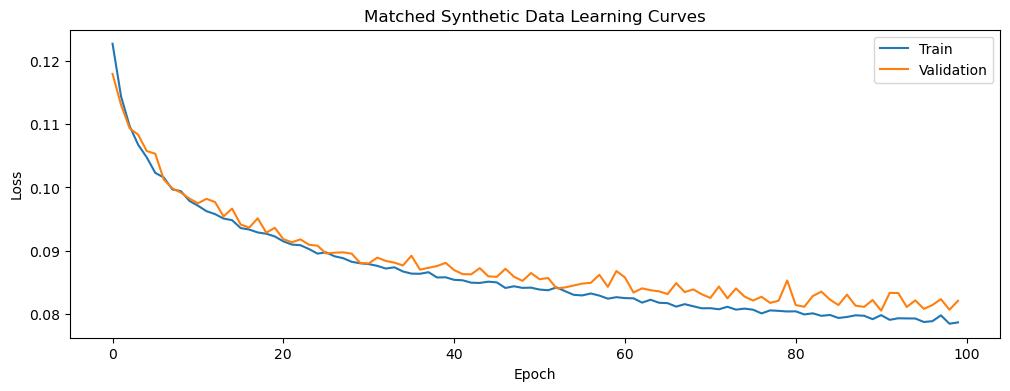

In [24]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12,4))
ax.plot(history_matched.history["loss"], label="Train")
ax.plot(history_matched.history["val_loss"], label="Validation")
ax.set_title("Matched Synthetic Data Learning Curves")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
plt.show()

In [25]:
eval_with_units(
    "Matched Data Transfer Model",
    transfer_model_matched,
    x_matched_test_s,
    y_matched_test_s,
    scy,
    y_is_scaled=True,
    t_hit_in_seconds=True
)


Matched Data Transfer Model
target unit     MAE      RMSE  STD_abs_error
 x_hit   mm  81.340   106.692         69.044
 y_hit   mm  85.980   121.588         85.972
 z_hit   mm  41.404    52.026         31.504
vx_hit mm/s 148.492   188.454        116.039
vy_hit mm/s 179.651   229.460        142.749
vz_hit mm/s 846.103 1,329.254      1,025.195
 t_hit   ms  30.927    45.409         33.249


## Loading the Real Dataset (Transfer Learning)

In [26]:
real_dataset = pd.read_csv('../learning_data/real_data/real_transfer_dataset_clean_4p.csv')
real_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 27 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   sample_id           80 non-null     int64  
 1   captured_at         80 non-null     object 
 2   x1                  80 non-null     float64
 3   y1                  80 non-null     float64
 4   z1                  80 non-null     float64
 5   x2                  80 non-null     float64
 6   y2                  80 non-null     float64
 7   z2                  80 non-null     float64
 8   x3                  80 non-null     float64
 9   y3                  80 non-null     float64
 10  z3                  80 non-null     float64
 11  x4                  80 non-null     float64
 12  y4                  80 non-null     float64
 13  z4                  80 non-null     float64
 14  dt12                80 non-null     float64
 15  dt23                80 non-null     float64
 16  dt34      

In [27]:
real_dataset.describe()

,sample_id,x1,y1,z1,x2,y2,z2,x3,y3,z3,...,x_hit,y_hit,z_hit,vx_hit,vy_hit,vz_hit,t_hit,is_reachable,intercept_valid,bounces_before_hit
count,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000,...,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000,80.0,80.0,80.000000
mean,47.125000,126.612093,2591.449725,-761.791921,126.761238,2513.987849,-775.495131,125.432742,2436.478162,-791.381096,...,76.342559,46.575018,-907.682583,-42.884910,-2385.960030,-278.552511,0.741691,1.0,1.0,1.125000
std,26.451472,271.347111,62.279668,171.448800,266.668826,67.252022,184.012954,261.782134,72.276213,195.976097,...,295.248039,97.102697,66.570062,330.544937,652.814734,1090.013869,0.183824,0.0,0.0,0.401737
min,1.000000,-371.352903,2474.123740,-1076.785318,-360.185295,2379.060989,-1110.802514,-360.406864,2286.534796,-1124.900432,...,-701.947682,-328.227102,-1019.507745,-1022.033907,-4597.915522,-3011.290991,0.382032,1.0,1.0,0.000000
25%,25.750000,-72.950039,2546.485334,-909.981788,-78.284393,2466.671439,-936.163130,-78.106019,2383.768672,-964.885410,...,-99.657641,-1.394730,-951.354162,-233.344772,-2767.130983,-1165.435303,0.621700,1.0,1.0,1.000000
50%,47.500000,109.521076,2579.879193,-760.515730,106.493038,2504.388456,-781.181150,103.027548,2431.891453,-800.763315,...,72.666277,27.231741,-907.160676,-27.869435,-2341.086691,-462.040608,0.718802,1.0,1.0,1.000000
75%,70.250000,309.993736,2627.887972,-619.762516,295.954137,2549.081834,-621.037727,281.874577,2481.585183,-626.871453,...,286.098751,82.785845,-860.487597,140.878215,-1914.624061,553.084686,0.847522,1.0,1.0,1.000000
max,91.000000,711.471532,2717.651305,-457.089021,698.851431,2661.683643,-454.160729,685.853714,2614.600661,-443.300851,...,701.506781,371.290518,-800.151669,874.429531,-1232.469961,1742.177354,1.241465,1.0,1.0,2.000000


### Pre-Processing the Real Dataset

In [28]:
x_real = real_dataset.iloc[:, 2:17]
y_real = real_dataset.iloc[:, 17:-3]

In [29]:
# View the inputs
print(x_real)

            x1           y1           z1          x2           y2  \
0   -93.085669  2546.231986  -918.175721  -66.675214  2465.409487   
1   253.280832  2618.434667  -887.696273  243.456673  2530.710133   
2   138.276373  2591.150386 -1007.428495  142.696882  2513.572280   
3    -4.816868  2545.514276  -862.061582   -0.465775  2463.644181   
4  -185.596759  2503.058353  -838.394090 -198.870946  2411.186734   
..         ...          ...          ...         ...          ...   
75  456.970889  2695.859462  -902.438977  458.953010  2631.602516   
76  -86.394866  2513.386321  -535.765480  -90.484254  2438.153943   
77  -69.582993  2546.569783  -555.203392  -89.055443  2467.092089   
78  109.369917  2590.155205  -744.746984  100.909601  2520.597169   
79  -83.051176  2533.622961  -547.087329  -90.578093  2445.765975   

             z2          x3           y3           z3          x4  \
0   -950.696625  -57.019999  2379.771476  -990.993770  -37.048924   
1   -922.622107  236.047704  2443

In [30]:
# View the inputs
print(y_real)

         x_hit       y_hit       z_hit      vx_hit       vy_hit       vz_hit  \
0   658.431426  186.145714 -892.452886  728.802670 -2081.964186   624.825909   
1   -33.169466  -23.127627 -949.963944 -276.611923 -2516.869388  1325.659844   
2   239.592959   12.987940 -923.123788   85.363122 -2191.648501  -780.166456   
3   405.096305   74.761886 -858.717278  341.693955 -2026.351570   331.536463   
4  -170.381534    1.371401 -896.207069  -10.085315 -2120.661508   467.959804   
..         ...         ...         ...         ...          ...          ...   
75  162.943001   10.345789 -932.164946 -215.711811 -1882.669877 -1260.136794   
76  -24.533740  -24.228500 -857.426613   61.761078 -2458.207609 -1405.678353   
77 -560.835984   87.400316 -821.190985 -535.798211 -2702.894023 -1009.420577   
78  -24.829500   -1.411993 -903.120639  -64.742114 -2010.803678    -4.368281   
79 -114.990334 -143.724057 -804.079048  -38.620152 -2764.857334  -862.659817   

       t_hit  
0   0.721709  
1   0.663

In [31]:
x_real = x_real.values
y_real = y_real.values

### Splitting the Dataset into the Training set and Test set

In [32]:
#Split input and output x, y
x_real_train, x_real_test, y_real_train, y_real_test= train_test_split(
    x_real, y_real,
    test_size=0.2,
    random_state=33

)


In [33]:
print(x_real_train.shape)
print(x_real_test.shape)
print(y_real_train.shape)
print(y_real_test.shape)

(64, 15)
(16, 15)
(64, 7)
(16, 7)


### Scaling the real dataset

In [34]:
x_real_train_s = scx.transform(x_real_train)
x_real_test_s = scx.transform(x_real_test)
y_real_train_s = scy.transform(y_real_train)
y_real_test_s = scy.transform(y_real_test)

In [35]:
# ### WEighting the xyz more than velocities

# # Output order must match your y columns:
# # [x_hit, y_hit, z_hit, vx_hit, vy_hit, vz_hit, t_hit]
# raw_w = tf.constant([10.0, 10.0, 10.0, 1.0, 1.0, 1.0, 5.0], dtype=tf.float32)

# # normalize so average weight is ~1 (keeps loss scale stable)
# output_weights = raw_w / tf.reduce_mean(raw_w)

# def weighted_mse(y_true, y_pred):
#     err2 = tf.square(y_true - y_pred)              # (batch, 7)
#     weighted_err2 = err2 * output_weights          # broadcast on 7 outputs
#     return tf.reduce_mean(weighted_err2)



## Training the New Layers (Classification Layers)

In [36]:


# Start from synthetic-pretrained weights
transfer_model = tf.keras.models.clone_model(transfer_model_matched)
transfer_model.set_weights(transfer_model_matched.get_weights())

# Stage 1: freeze first 2 layers
for layer in transfer_model.layers[:2]:
    layer.trainable = False

transfer_model.compile(
    loss="mean_squared_error",
    optimizer=Adam(learning_rate=5e-4),
    metrics=["mean_squared_error"]
)

# ###Weighted 
# transfer_model.compile(
#     loss=weighted_mse,
#     optimizer=Adam(learning_rate=5e-4),
#     metrics=["mean_squared_error"]  # still logs normal MSE too
# )


history_stage1 = transfer_model.fit(
    x_real_train_s, y_real_train_s,
    validation_split=0.2,
    epochs=150,
    verbose=1
)





Epoch 1/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 328ms/step - loss: 0.5259 - mean_squared_error: 0.5169 - val_loss: 0.4512 - val_mean_squared_error: 0.4421
Epoch 2/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 0.4684 - mean_squared_error: 0.4594 - val_loss: 0.4092 - val_mean_squared_error: 0.4002
Epoch 3/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.4165 - mean_squared_error: 0.4075 - val_loss: 0.3738 - val_mean_squared_error: 0.3648
Epoch 4/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 0.3744 - mean_squared_error: 0.3654 - val_loss: 0.3435 - val_mean_squared_error: 0.3345
Epoch 5/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.3356 - mean_squared_error: 0.3266 - val_loss: 0.3175 - val_mean_squared_error: 0.3085
Epoch 6/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 0.3033 - mean_squared_error: 0.2943 - val_loss: 0.2952 - val_mean_squared_error: 0.2862
Epoch 7/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.2735 - mean_squared_error: 0.2645 - val_loss: 0.2765 - val_mean

## Stage 1 Validation Curve

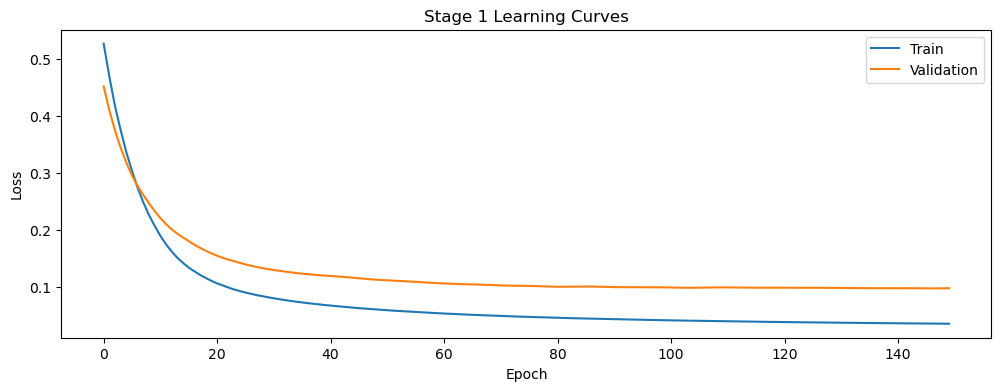

In [37]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12,4))
ax.plot(history_stage1.history["loss"], label="Train")
ax.plot(history_stage1.history["val_loss"], label="Validation")
ax.set_title("Stage 1 Learning Curves")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
plt.show()


In [38]:
eval_with_units(
    "Stage 1 Transfer Model - Real Test",
    transfer_model,
    x_real_test_s,
    y_real_test_s,
    scy,
    y_is_scaled=True,
    t_hit_in_seconds=True
)




Stage 1 Transfer Model - Real Test
target unit     MAE      RMSE  STD_abs_error
 x_hit   mm 101.490   139.159         95.210
 y_hit   mm  44.328    53.966         30.779
 z_hit   mm  51.050    62.475         36.014
vx_hit mm/s 112.570   158.763        111.954
vy_hit mm/s 250.368   327.350        210.888
vz_hit mm/s 851.801 1,036.829        591.143
 t_hit   ms  62.318    76.130         43.730


In [39]:


def snapshot_model(model):
    m = tf.keras.models.clone_model(model)
    m.set_weights(model.get_weights())
    return m

# # Weighted Version
# def snapshot_model(model):
#     with tf.keras.utils.custom_object_scope({'weighted_mse': weighted_mse}):
#         m = tf.keras.models.clone_model(model)
#     m.set_weights(model.get_weights())
#     return m
    
# --- run this RIGHT AFTER stage 1 training/eval ---
stage1_model = snapshot_model(transfer_model)
print("Saved stage1_model snapshot.")


Saved stage1_model snapshot.


In [40]:
# Stage 2: unfreeze all layers
for layer in transfer_model.layers:
    layer.trainable = True

transfer_model.compile(
    loss="mean_squared_error",
    optimizer=Adam(learning_rate=1e-5),
    metrics=["mean_squared_error"]
)

# ###Weighted 
# transfer_model.compile(
#     loss=weighted_mse,
#     optimizer=Adam(learning_rate=1e-5),
#     metrics=["mean_squared_error"]
# )


history_stage2 = transfer_model.fit(
    x_real_train_s, y_real_train_s,
    validation_split=0.2,
    epochs=100,
    verbose=1
)



Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 269ms/step - loss: 0.0886 - mean_squared_error: 0.0269 - val_loss: 0.1507 - val_mean_squared_error: 0.0889
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.0885 - mean_squared_error: 0.0268 - val_loss: 0.1506 - val_mean_squared_error: 0.0888
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.0885 - mean_squared_error: 0.0267 - val_loss: 0.1504 - val_mean_squared_error: 0.0887
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.0884 - mean_squared_error: 0.0267 - val_loss: 0.1503 - val_mean_squared_error: 0.0886
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.0884 - mean_squared_error: 0.0267 - val_loss: 0.1502 - val_mean_squared_error: 0.0885
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.0884 - mean_squared_error: 0.0266 - val_loss: 0.1501 - val_mean_squared_error: 0.0884
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.0883 - mean_squared_error: 0.0266 - val_loss: 0.1501 - val_mean

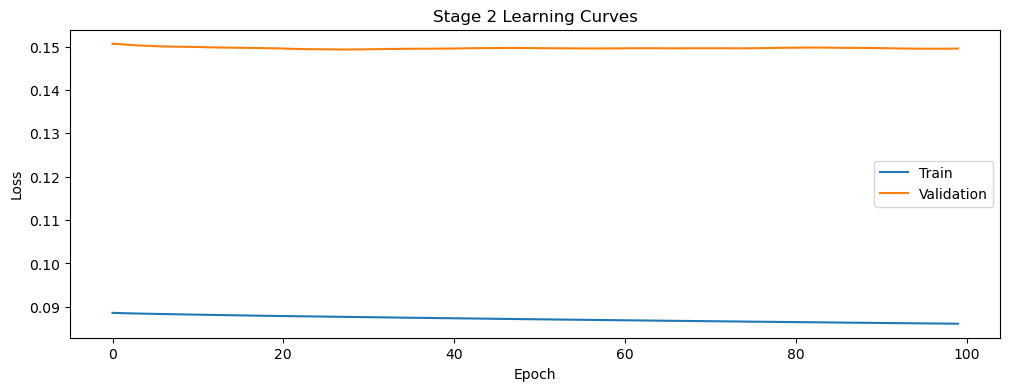

In [41]:
fig, ax = plt.subplots(figsize=(12,4))
ax.plot(history_stage2.history["loss"], label="Train")
ax.plot(history_stage2.history["val_loss"], label="Validation")
ax.set_title("Stage 2 Learning Curves")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
plt.show()


In [42]:
eval_with_units(
    "Stage 2 Final Transfer Model - Real Test",
    transfer_model,
    x_real_test_s,
    y_real_test_s,
    scy,
    y_is_scaled=True,
    t_hit_in_seconds=True
)




Stage 2 Final Transfer Model - Real Test
target unit     MAE      RMSE  STD_abs_error
 x_hit   mm  99.132   138.787         97.132
 y_hit   mm  42.934    53.403         31.757
 z_hit   mm  50.488    61.872         35.764
vx_hit mm/s 100.323   150.703        112.457
vy_hit mm/s 235.240   306.354        196.252
vz_hit mm/s 846.811 1,035.139        595.335
 t_hit   ms  59.717    71.907         40.056


In [43]:
stage2_model = snapshot_model(transfer_model)
print("Saved stage2_model snapshot.")

# --- run once (any time after broad + matched are trained) ---
broad_model = snapshot_model(ball_predictor)
matched_model = snapshot_model(transfer_model_matched)
print("Saved broad_model and matched_model snapshots.")




Saved stage2_model snapshot.
Saved broad_model and matched_model snapshots.


In [44]:
# --- final comparison on real test set ---
eval_with_units("Broad model - Real Test",   broad_model,   x_real_test_s, y_real_test_s, scy, y_is_scaled=True, t_hit_in_seconds=True)
eval_with_units("Matched model - Real Test", matched_model, x_real_test_s, y_real_test_s, scy, y_is_scaled=True, t_hit_in_seconds=True)
eval_with_units("Stage 1 model - Real Test", stage1_model,  x_real_test_s, y_real_test_s, scy, y_is_scaled=True, t_hit_in_seconds=True)
eval_with_units("Stage 2 model - Real Test", stage2_model,  x_real_test_s, y_real_test_s, scy, y_is_scaled=True, t_hit_in_seconds=True)




Broad model - Real Test
target unit       MAE      RMSE  STD_abs_error
 x_hit   mm   111.790   149.217         98.836
 y_hit   mm    72.087    86.697         48.165
 z_hit   mm   218.096   249.294        120.755
vx_hit mm/s   449.739   523.647        268.218
vy_hit mm/s 2,567.491 2,660.760        698.310
vz_hit mm/s 1,467.149 1,672.633        803.228
 t_hit   ms   247.735   278.336        126.878

Matched model - Real Test
target unit       MAE      RMSE  STD_abs_error
 x_hit   mm    82.032   123.673         92.552
 y_hit   mm    97.479   114.019         59.145
 z_hit   mm   108.585   120.249         51.664
vx_hit mm/s   420.240   487.003        246.111
vy_hit mm/s 2,582.426 2,641.694        556.434
vz_hit mm/s 1,680.064 1,929.665        949.206
 t_hit   ms   233.381   253.860         99.891

Stage 1 model - Real Test
target unit     MAE      RMSE  STD_abs_error
 x_hit   mm 101.490   139.159         95.210
 y_hit   mm  44.328    53.966         30.779
 z_hit   mm  51.050    62.475     

In [45]:
from pathlib import Path
import joblib

export_dir = Path("../models/ann_stage2_4pt")
export_dir.mkdir(parents=True, exist_ok=True)

deploy_model = stage2_model   # or transfer_model / matched_model / broad_model
deploy_model.save(export_dir / "ball_predictor_4point.keras")
joblib.dump(scx, export_dir / "scx_4point.joblib")
joblib.dump(scy, export_dir / "scy_4point.joblib")

print("Saved model + scalers to:", export_dir.resolve())


Saved model + scalers to: C:\Users\rocky\Personal\UBC\Year 4\IGEN 430\TableTennis_Software_Firmware\transfer_learning\models\ann_stage2_4pt
